In [4]:
from rocketpy import Environment, Flight, Function, MonteCarlo, Rocket, SolidMotor
from rocketpy.stochastic import StochasticEnvironment, StochasticFlight, StochasticNoseCone, StochasticParachute, StochasticRailButtons, StochasticRocket, StochasticSolidMotor, StochasticTail, StochasticTrapezoidalFins
from rocketpy.simulation import FlightDataExporter
import datetime, os, simplekml

Vento_Leste-Oeste: -1.01
Vento_Norte-Sul: -0.12

Gravity Details

Acceleration of gravity at surface level:    9.7904 m/s²
Acceleration of gravity at  14.206 km (ASL): 9.7468 m/s²


Launch Site Details

Launch Date: 2026-09-10 12:30:00 UTC
Launch Site Latitude: -26.30530°
Launch Site Longitude: -48.93605°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 106924.09 W    7084515.40 S
Launch Site UTM zone: 23J
Launch Site Surface Elevation: 24.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 14.206 km

Surface Atmospheric Conditions

Surface Wind Speed: 1.02 m/s
Surface Wind Direction: 83.22°
Surface Wind Heading: 263.22°
Surface Pressure: 1000.00 hPa
Surface Temperature: 296.77 K
Surface Air Density: 1.174 kg/m³
Surface Speed of Sound: 345.35 m/s


Earth Model Details

Earth Radius at Launch site: 6373.97 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



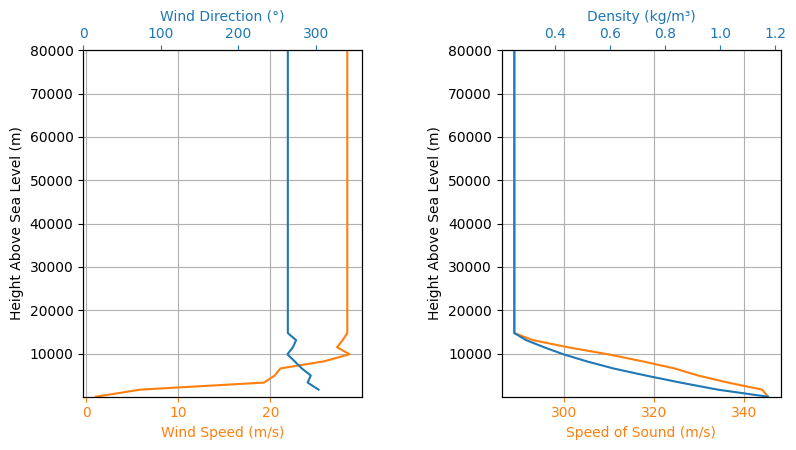

In [5]:
# Aeródromo Aerocircus
env = Environment(
    latitude = -26.30530456662508,
    longitude = -48.936049614389546,
    elevation = 24,
    timezone = "America/Sao_Paulo"
)
lancamento = datetime.datetime.fromisoformat("2026-09-10 12:30:00")
env.set_date(lancamento)
env.set_atmospheric_model(type = "Windy", file = "GFS")
#env.set_atmospheric_model(type="standard_atmosphere")

# Componentes do vento na superfície (altitude = 0 m AGL)
print("Vento_Leste-Oeste:", env.wind_velocity_x(0))                 # > 0 = Leste
print("Vento_Norte-Sul:", env.wind_velocity_y(0))                   # > 0 = Norte
env.info()

Nozzle Details
Nozzle Radius: 0.00749 m
Nozzle Throat Radius: 0.00325 m

Grain Details
Number of Grains: 2
Grain Spacing: 0.002 m
Grain Density: 1535.5 kg/m3
Grain Outer Radius: 0.015962 m
Grain Inner Radius: 0.00635 m
Grain Height: 0.055 m
Grain Volume: 0.000 m3
Grain Mass: 0.057 kg

Motor Details
Total Burning Time: 1.74 s
Total Propellant Mass: 0.114 kg
Structural Mass Ratio: 0.599
Average Propellant Exhaust Velocity: 807.435 m/s
Average Thrust: 52.808 N
Maximum Thrust: 87.4 N at 0.611 s after ignition.
Total Impulse: 91.887 Ns



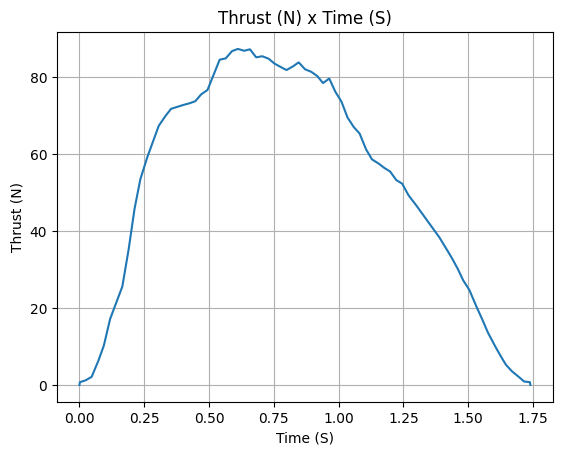

In [9]:
MARI = SolidMotor(
  thrust_source = r"C:\Users\User\OneDrive\Documentos\Kosmos\KOSMOSGit\Projetos 2026\FTK\FTKPY\MARI TESTE.eng",

  dry_mass = 0.170,
  center_of_dry_mass_position = 0.088263,
  dry_inertia = (0.0008639, 0.0008639, 0.000061918801),

  nozzle_position = 0,
  nozzle_radius = 0.00749,
  throat_radius = 0.00325,

  grain_number = 2,
  grain_separation = 0.002,
  grain_density = 1535.5,
  grain_outer_radius = 0.015962,
  grain_initial_inner_radius = 0.00635,
  grain_initial_height = 0.055,
  grains_center_of_mass_position = 0.087179,
  
  burn_time = 1.74,
  
  coordinate_system_orientation = "nozzle_to_combustion_chamber",
  interpolation_method = "linear",
  reshape_thrust_curve = False
)
MARI.info()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\rocketpy\mathutils\_calc\polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)



Inertia Details

Rocket Mass: 1.373 kg (without motor)
Rocket Dry Mass: 1.543 kg (with unloaded motor)
Rocket Loaded Mass: 1.657 kg
Rocket Structural Mass Ratio: 0.931
Rocket Inertia (with unloaded motor) 11: 0.374 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.374 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.003 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.03415 m
Rocket Frontal Area: 0.003664 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.042 m
Rocket Center of Dry Mass - Nozzle Exit: 0.432 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.344 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.024 m


Aerodynamics Lift Coefficient Derivatives


Center of Pressure


Stability

Center of Mass position (time=0): 0.456 m
Center of Pressure position (time=0): 0.000 

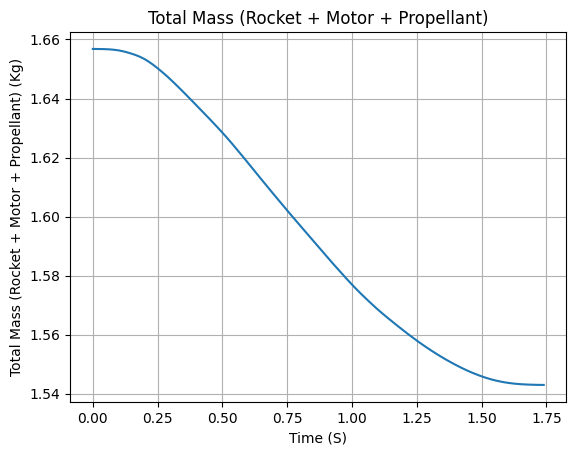

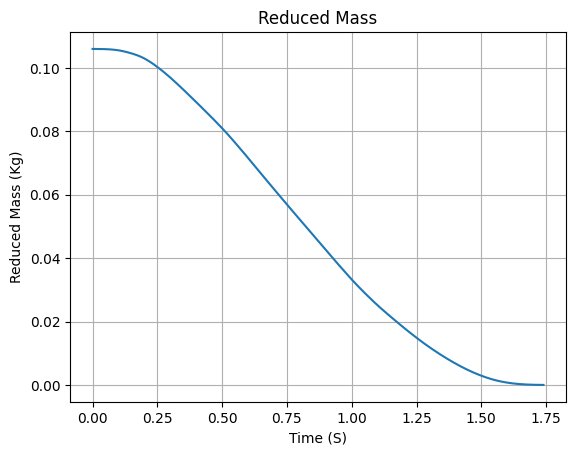


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


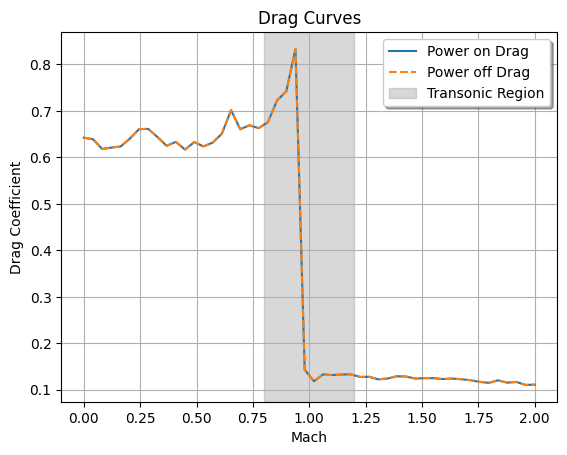


Stability Plots
--------------------


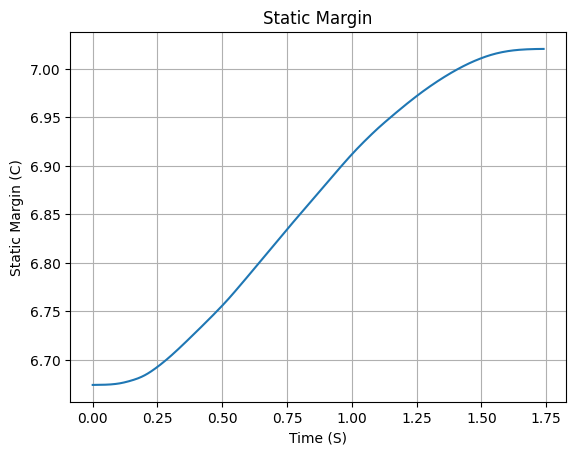

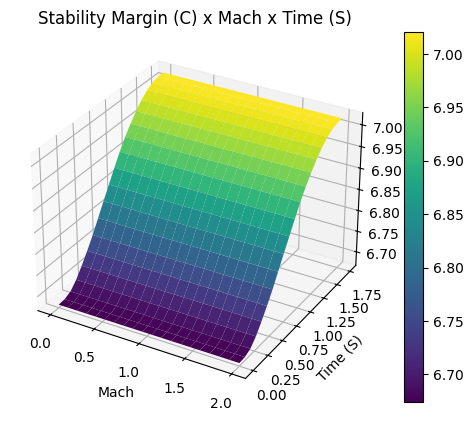


Thrust-to-Weight Plot
----------------------------------------


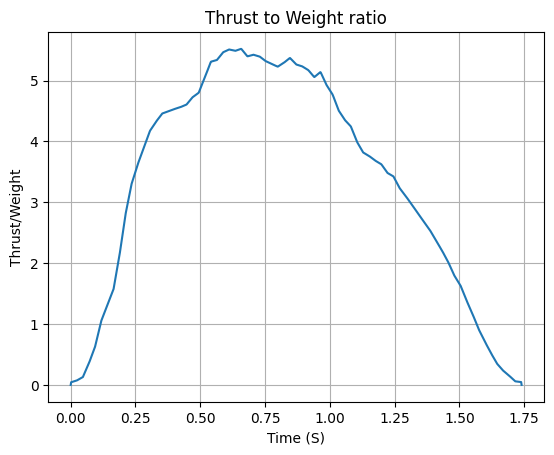

In [10]:
FTK = Rocket(
    radius = 0.03415,                                               
    mass = 1.373,
    center_of_mass_without_motor = 0.522,                                                  
    inertia = (0.3502,0.3502,2.6608e-3),                            
                             
    power_off_drag = r"C:\Users\User\OneDrive\Documentos\Kosmos\KOSMOSGit\Projetos 2026\FTK\FTKPY\CSVs\FTKOFF.csv",
    power_on_drag = r"C:\Users\User\OneDrive\Documentos\Kosmos\KOSMOSGit\Projetos 2026\FTK\FTKPY\CSVs\FTKON.csv",
    
    coordinate_system_orientation = "tail_to_nose"
)
FTK.add_motor(MARI, position = 0.048)
FTK.all_info()

In [11]:
coifa = FTK.add_nose(
    length = 0.125, 
    kind = "elliptical", 
    position = 1.01
)

guias = FTK.set_rail_buttons(
    upper_button_position = 0.58,
    lower_button_position = 0.07,
    angular_position = 45
)

aletas = FTK.add_trapezoidal_fins(
    n = 4,
    root_chord = 0.09,
    tip_chord = 0.035,
    span = 0.08,
    sweep_length = 0.095,
    position = 0.153
)

boattail = FTK.add_tail(
    top_radius = 0.03415, 
    bottom_radius = 0.024, 
    length = 0.066, 
    position = 0.066
)

paraquedas = FTK.add_parachute(
    name = "cross",
    cd_s = 0.952,
    trigger = "apogee",             # Ejeção
    sampling_rate = 105,
    lag = 1,                        # Atraso de abertura do paraquedas s
    height = 0.4,
    drag_coefficient = 0.85
)

Identification of the AeroSurface:
----------------------------------
Name: Nose Cone
Python Class: <class 'rocketpy.rocket.aero_surface.nose_cone.NoseCone'>

Geometric information of NoseCone:
----------------------------------
Length: 0.125 m
Kind: elliptical
Base radius: 0.034 m
Reference rocket radius: 0.034 m
Reference radius ratio: 1.000

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.042)
Lift coefficient derivative at Mach 0 and AoA 0: 2.000 1/rad



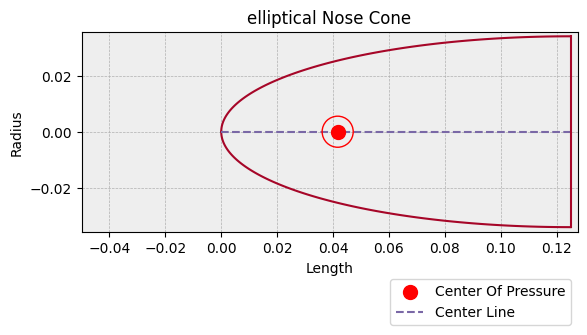

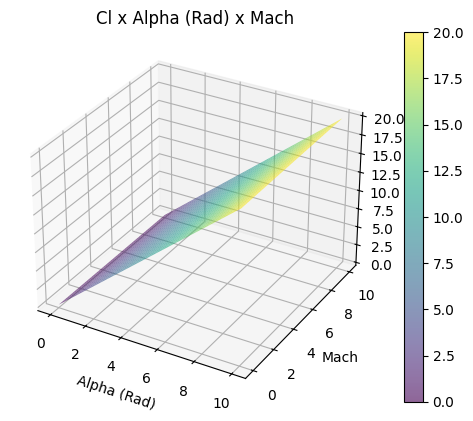

Identification of the AeroSurface:
----------------------------------
Name: Rail Buttons
Python Class: <class 'rocketpy.rocket.aero_surface.rail_buttons.RailButtons'>

Geometric information of the RailButtons:
-----------------------------------------
Distance from one button to the other: 0.510 m
Angular position of the buttons: 45.000 deg

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.000)
Lift coefficient derivative at Mach 0 and AoA 0: 0.000 1/rad

Identification of the AeroSurface:
----------------------------------
Name: Fins
Python Class: <class 'rocketpy.rocket.aero_surface.fins.trapezoidal_fins.TrapezoidalFins'>

Geometric information of the fin set:
-------------------------------------
Number of fins: 4
Reference rocket radius: 0.034 m
Tip chord: 0.035 m
Root chord: 0.090 m
Span: 0.080 m
Cant angle: 0.000 ° or 0.000 rad
Longitudinal section area: 0.005 m²
Aspect ratio: 2.560 
Gamma_

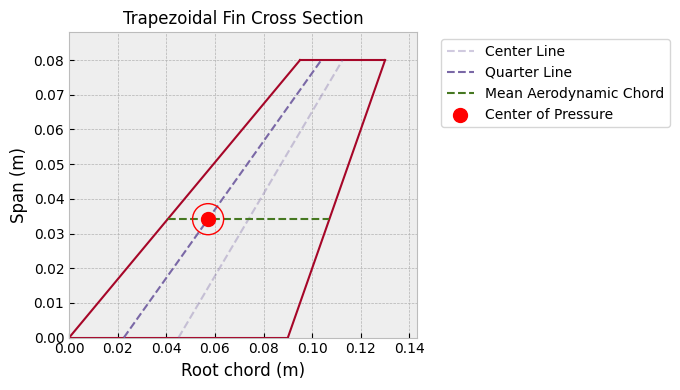

Roll parameters:


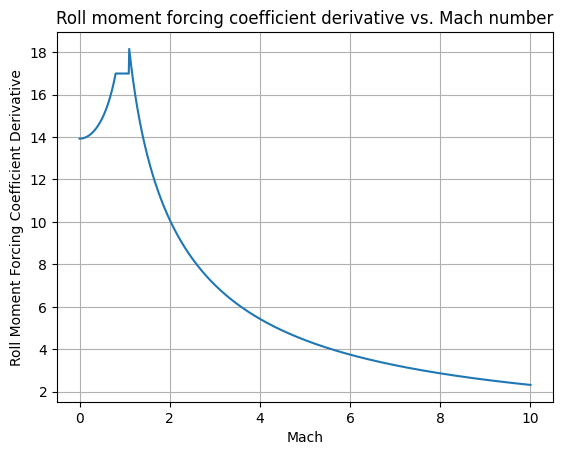

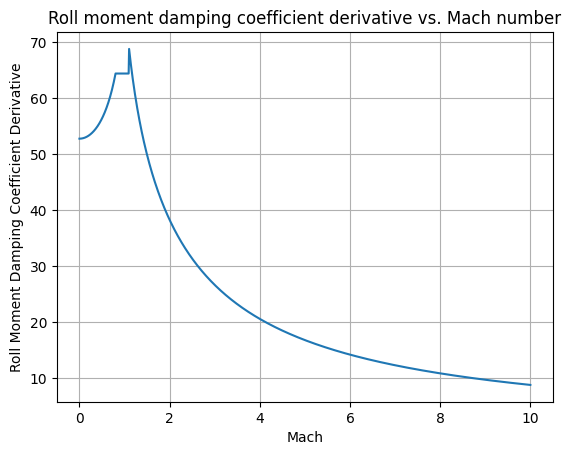

Lift coefficient:


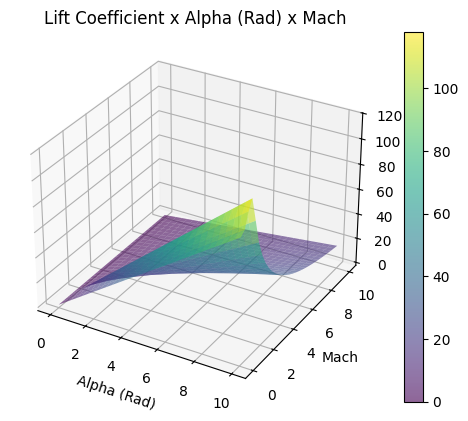

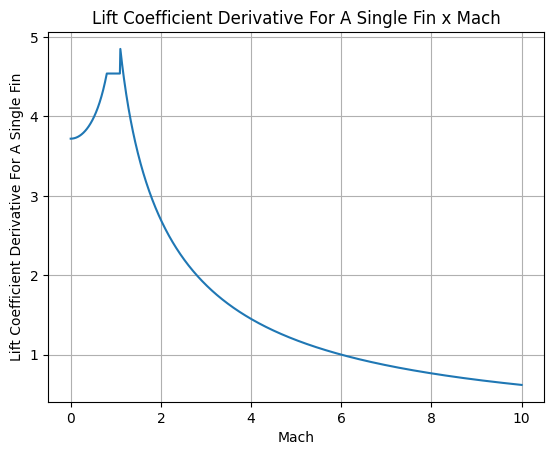

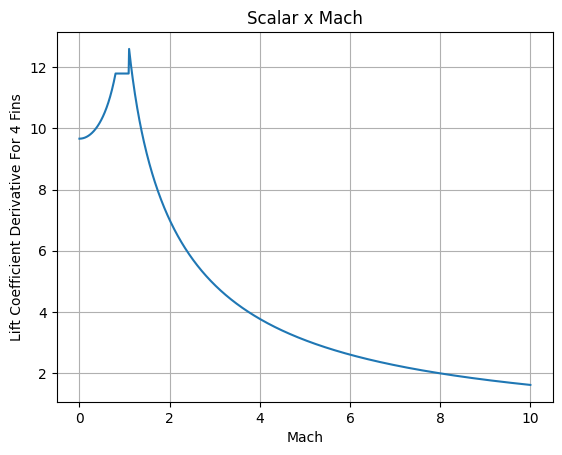

Identification of the AeroSurface:
----------------------------------
Name: Tail
Python Class: <class 'rocketpy.rocket.aero_surface.tail.Tail'>

Geometric information of the Tail:
----------------------------------
Top radius: 0.034 m
Bottom radius: 0.024 m
Reference radius: 0.068 m
Length: 0.066 m
Slant length: 0.067 m
Surface area: 0.012199 m²

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.031)
Lift coefficient derivative at Mach 0 and AoA 0: -1.012 1/rad



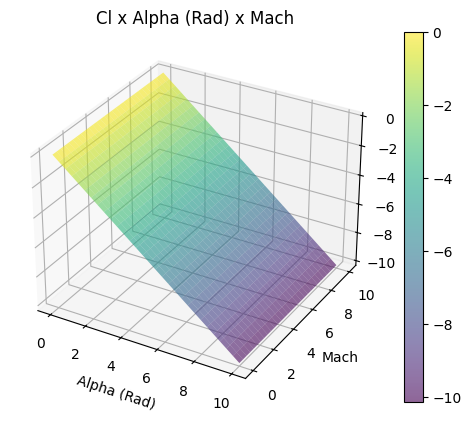


Parachute Details

Parachute Cross with a cd_s of 0.9520 m2
Ejection signal trigger: At Apogee
Ejection system refresh rate: 105.000 Hz
Time between ejection signal is triggered and the parachute is fully opened: 1.0 s


Inertia Details

Rocket Mass: 1.373 kg (without motor)
Rocket Dry Mass: 1.543 kg (with unloaded motor)
Rocket Loaded Mass: 1.657 kg
Rocket Structural Mass Ratio: 0.931
Rocket Inertia (with unloaded motor) 11: 0.374 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.374 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.003 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.03415 m
Rocket Frontal Area: 0.003664 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.042 m
Rocket Center of Dry Mass - Nozzle Exit: 0.432 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.344 m
Rocke

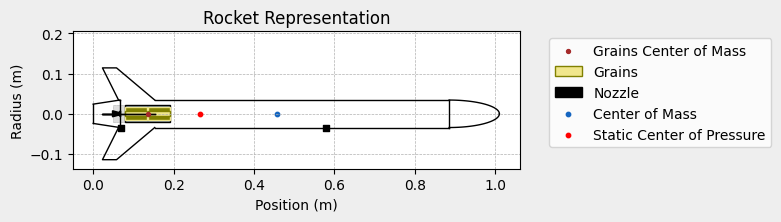


Mass Plots
----------------------------------------


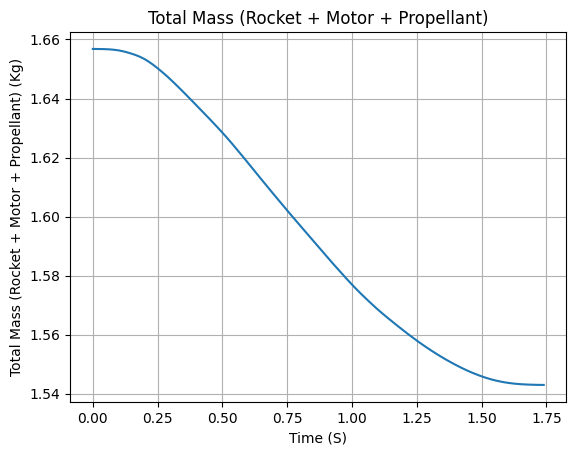

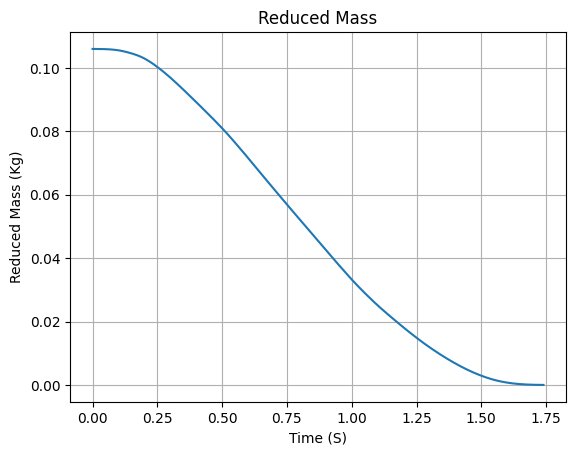


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


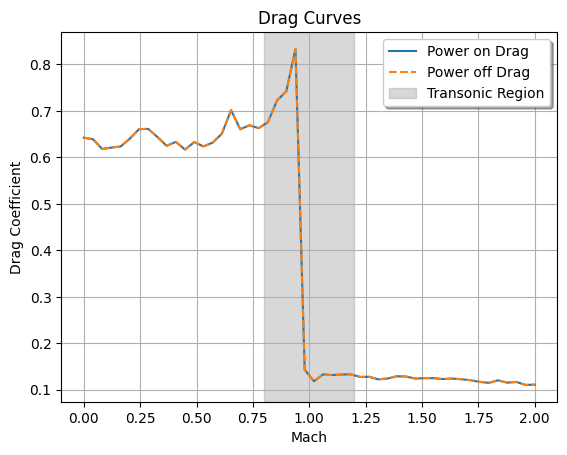


Stability Plots
--------------------


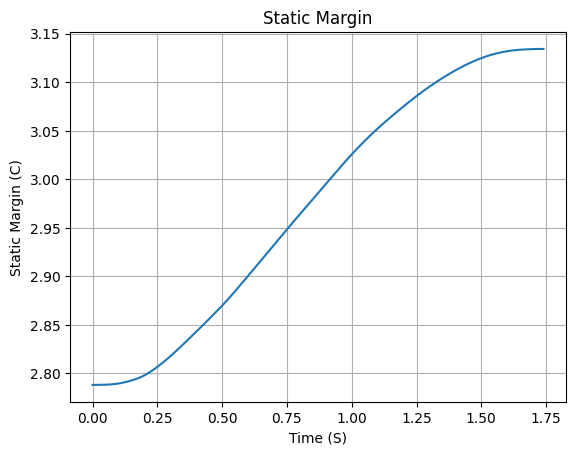

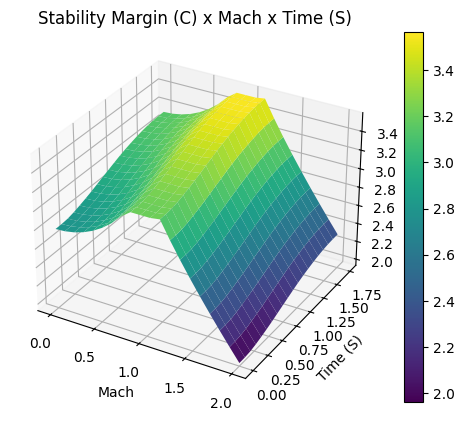


Thrust-to-Weight Plot
----------------------------------------


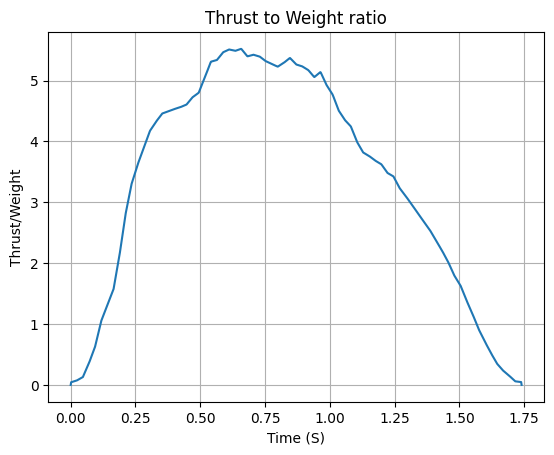

In [12]:
coifa.all_info()
guias.all_info()
aletas.all_info()
boattail.all_info()
paraquedas.all_info()
FTK.all_info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 24.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.606 | e1: 0.011 | e2: 0.086 | e3: -0.790
Euler Angles - Spin φ : 45.00° | Nutation θ: -10.00° | Precession ψ: -150.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.788 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.40 m/s
Lateral Surface Wind Speed: -0.93 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 80.00°
Launch Rail Heading: 150.00°


Rail Departure State

Rail Departure Time: 0.656 s
Rail Departure Velocity: 16.486 m/s
Rail Departure Stability Margin: 2.920 c
Rail Departure Angle of Attack: 3.507°
Rail Departure Thrust-Weight Ratio: 5.520
Rail Departure Reynolds Number: 7.264e+04


Burn out State

Burn out time: 1.740 s
Altitude at burn out: 63.362 m (ASL) | 39.362 m (AGL)
Rocket speed at burn out: 40.338 m/s
Freestream veloci

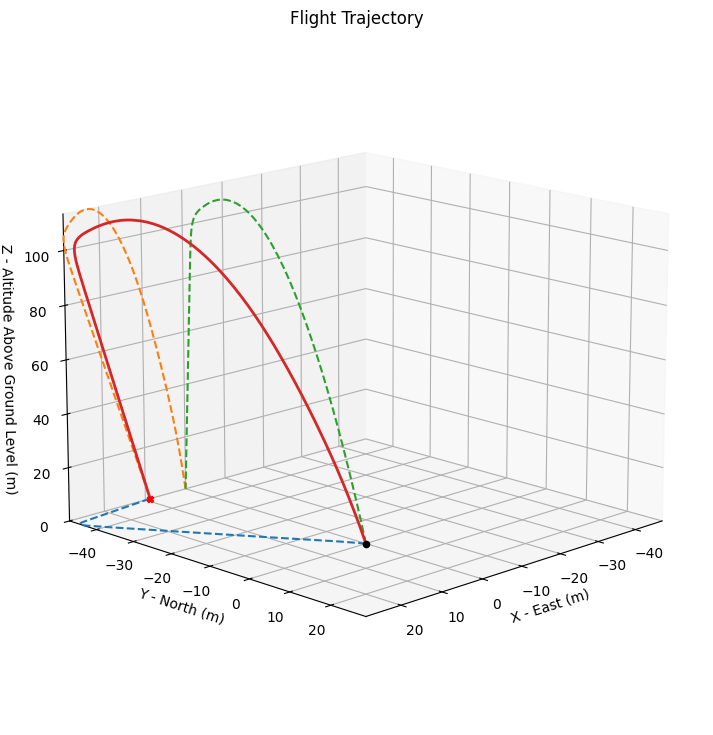



Trajectory Kinematic Plots



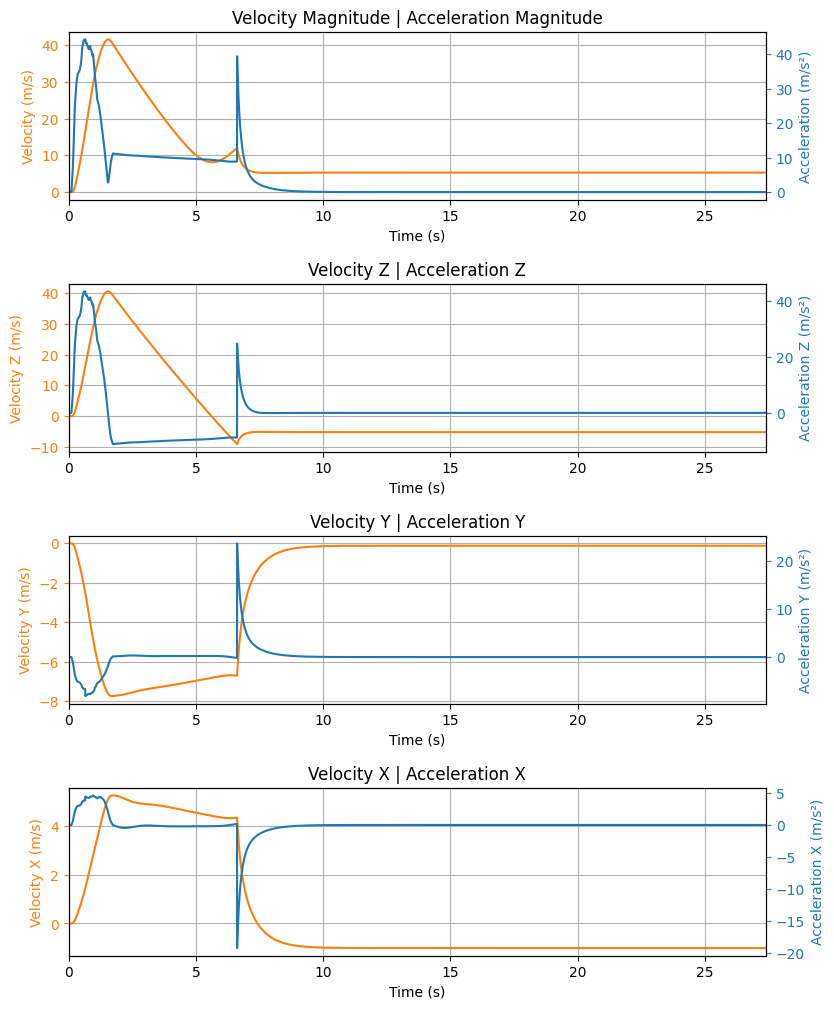



Angular Position Plots



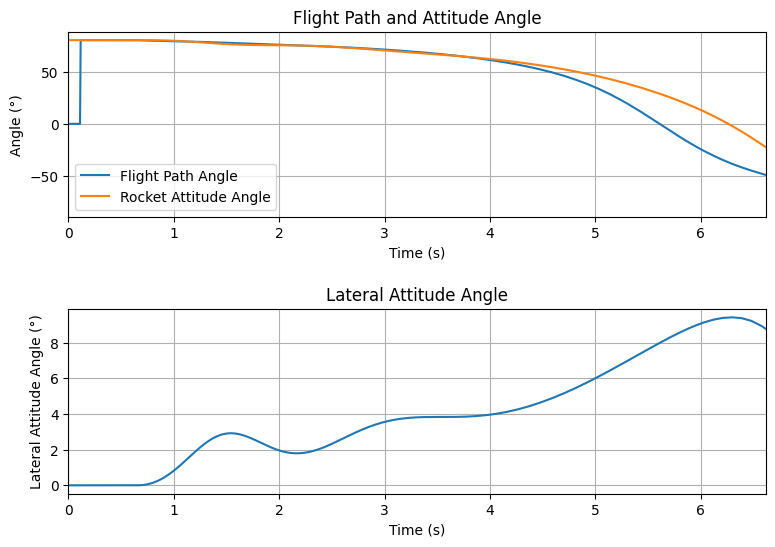



Path, Attitude and Lateral Attitude Angle Plots



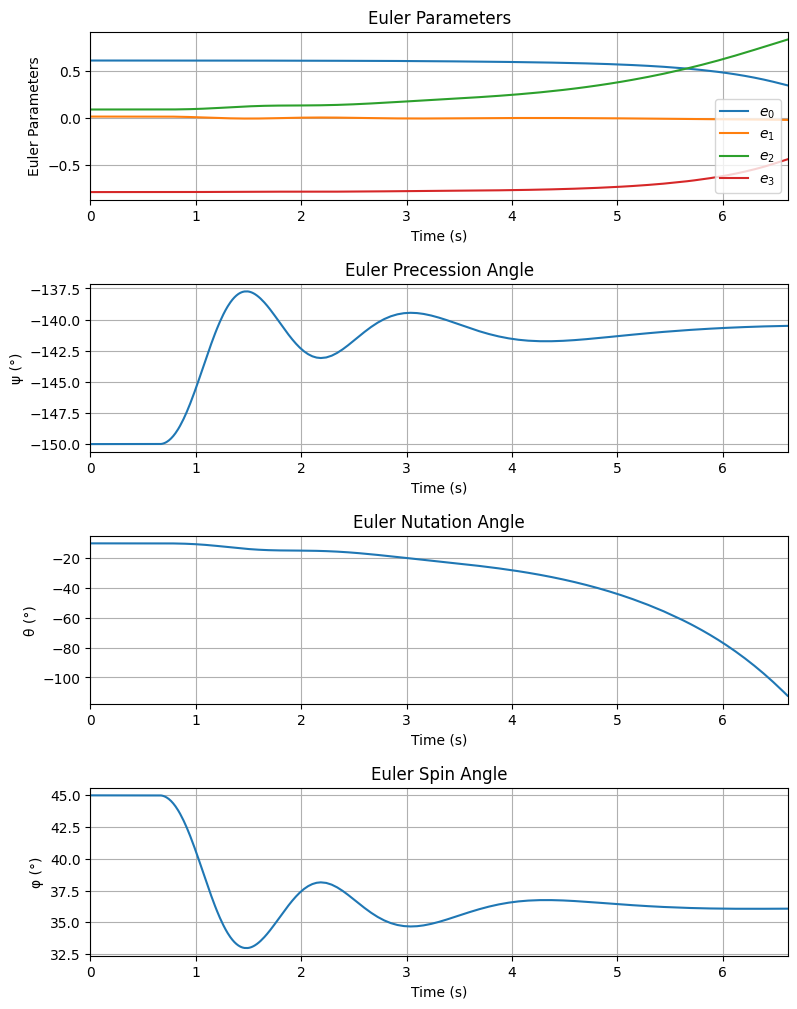



Trajectory Angular Velocity and Acceleration Plots



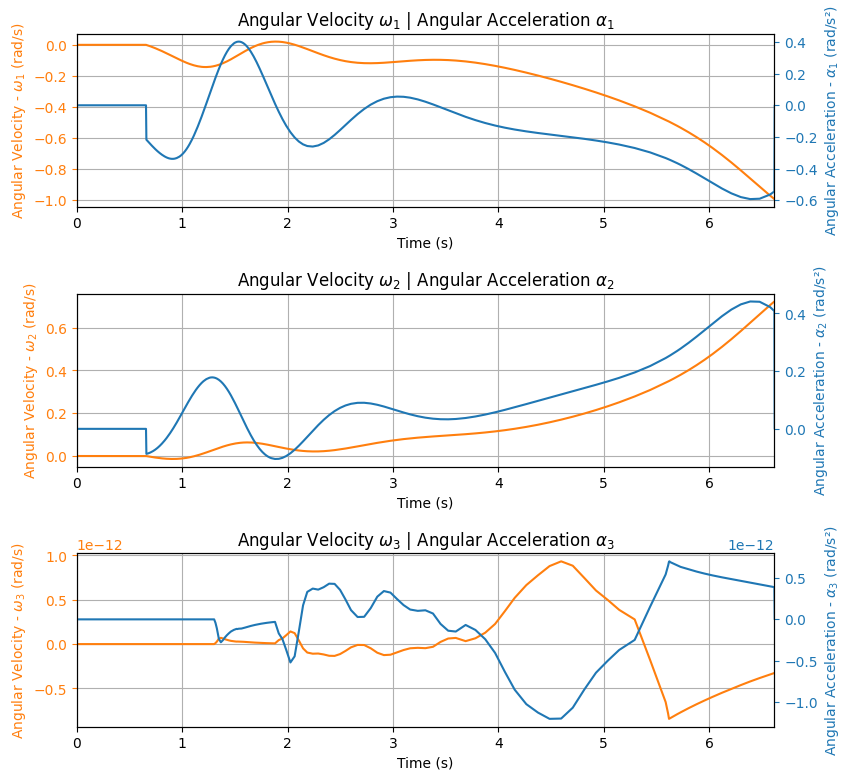



Aerodynamic Forces Plots



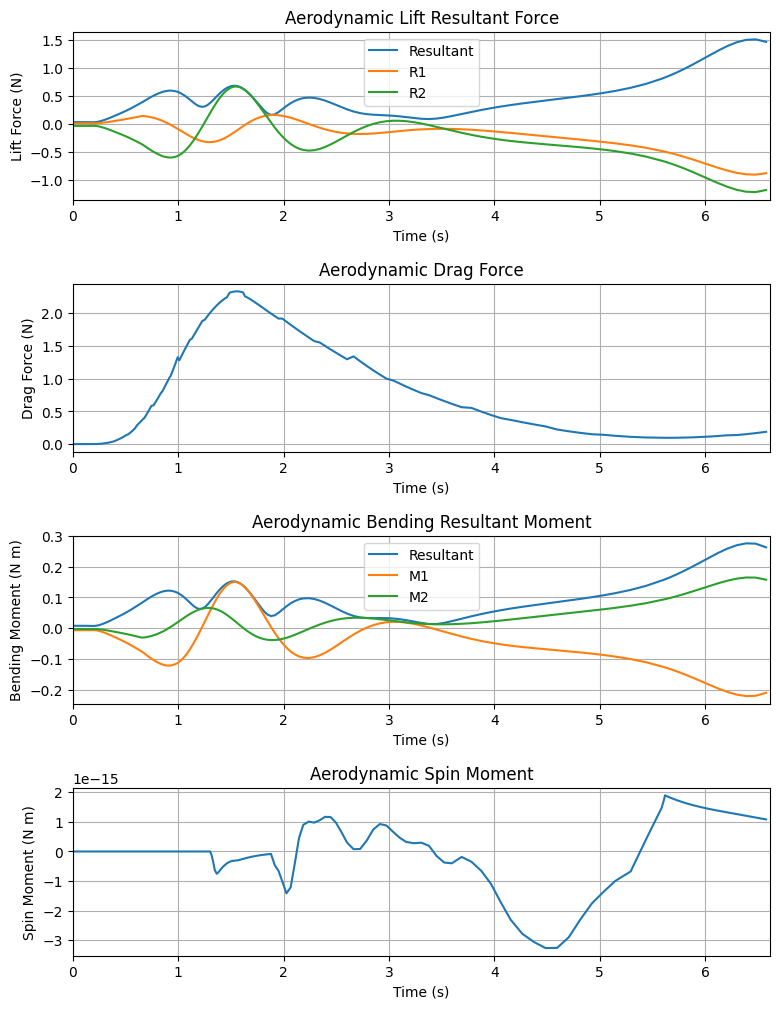

Rail button height not defined. Skipping bending moment plots.




Rail Buttons Bending Moments Plots



Rail Buttons Forces Plots



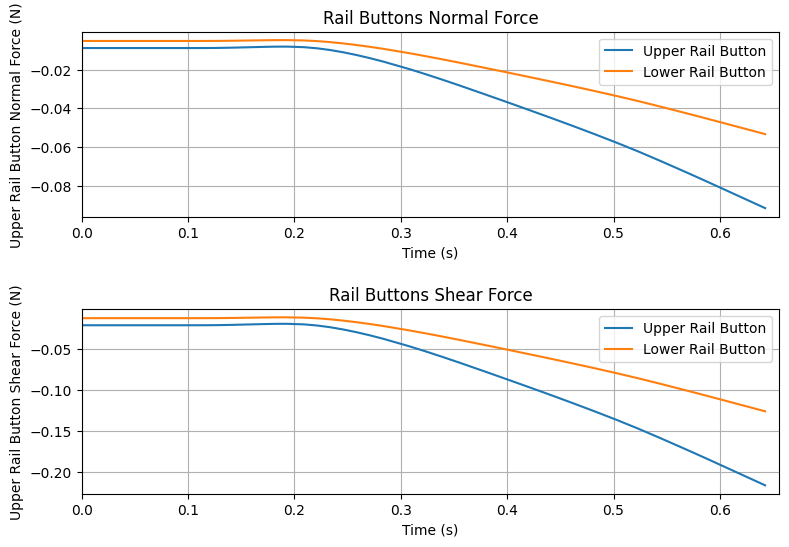



Trajectory Energy Plots



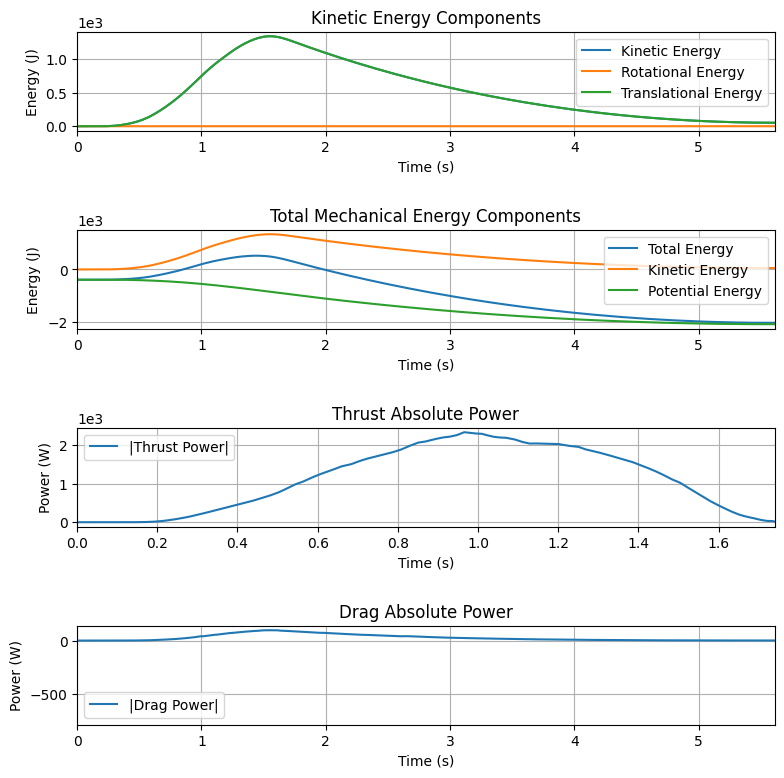



Trajectory Fluid Mechanics Plots



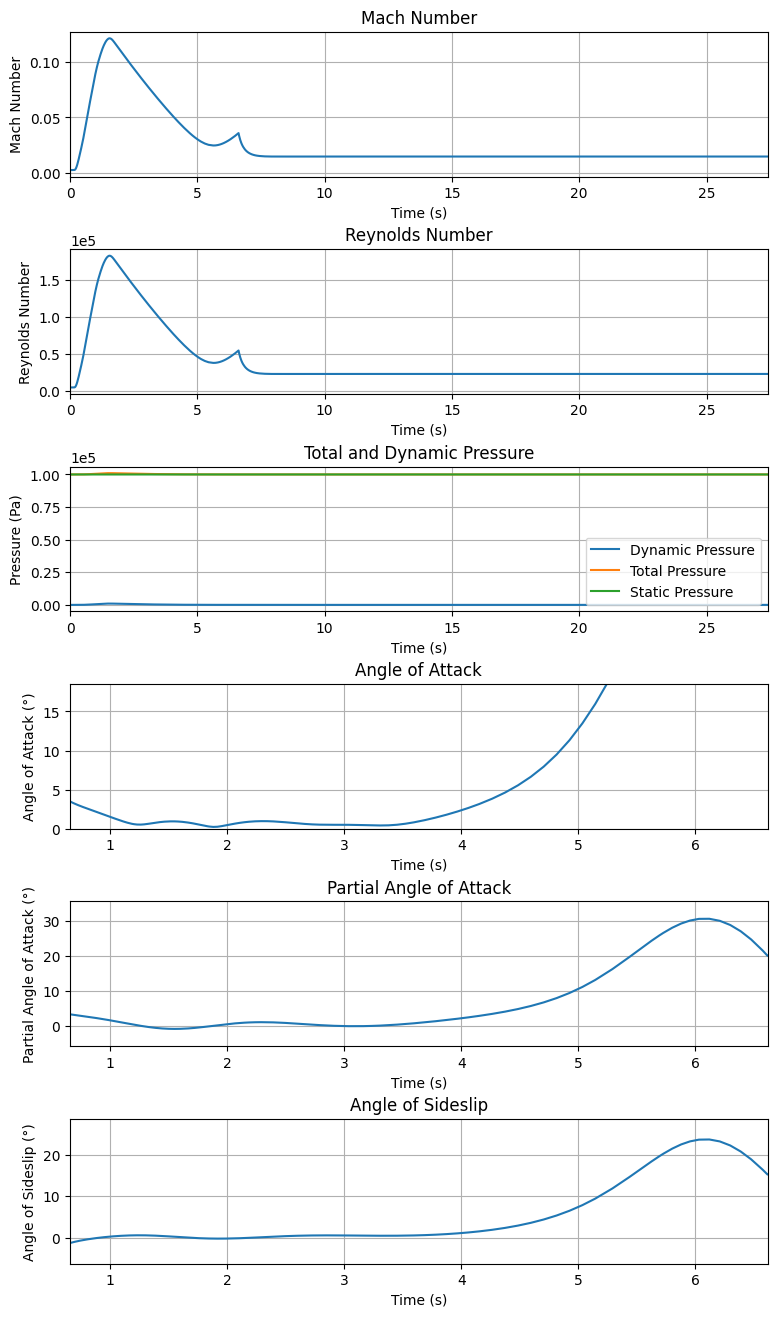



Trajectory Stability and Control Plots



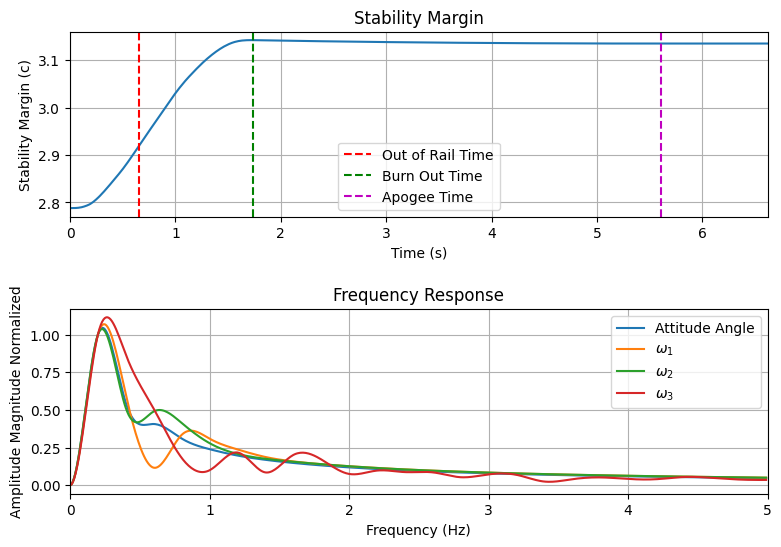



Rocket and Parachute Pressure Plots



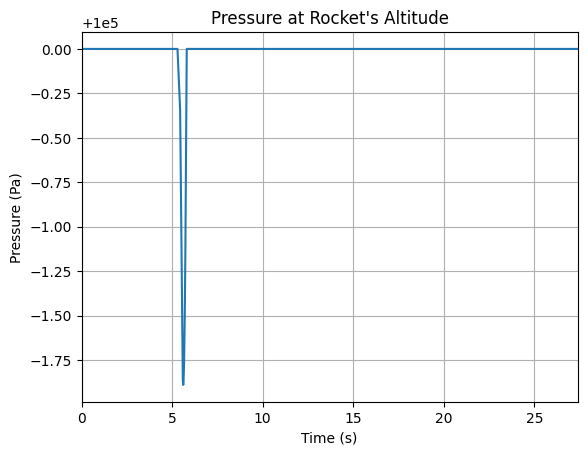

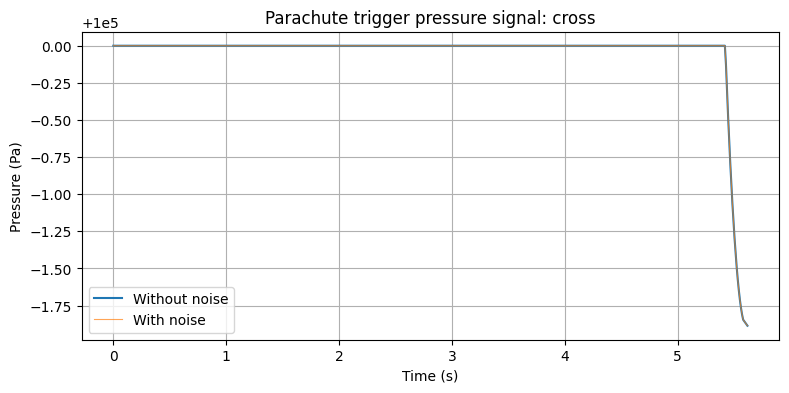

In [13]:
test_flight = Flight(
    rocket = FTK, 
    environment = env, 
    rail_length = 4, 
    inclination = 80, 
    heading = 150, 
    max_time = 180,
)
test_flight.all_info()

In [14]:
test_flight.env.latitude
test_flight.env.longitude
test_flight.env.elevation
test_flight.prints.out_of_rail_conditions()
test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
test_flight.prints.events_registered()
test_flight.prints.impact_conditions()
test_flight.prints.maximum_values()


Rail Departure State

Rail Departure Time: 0.656 s
Rail Departure Velocity: 16.486 m/s
Rail Departure Stability Margin: 2.920 c
Rail Departure Angle of Attack: 3.507°
Rail Departure Thrust-Weight Ratio: 5.520
Rail Departure Reynolds Number: 7.264e+04

Burn out State

Burn out time: 1.740 s
Altitude at burn out: 63.362 m (ASL) | 39.362 m (AGL)
Rocket speed at burn out: 40.338 m/s
Freestream velocity at burn out: 40.459 m/s
Mach Number at burn out: 0.117
Kinetic energy at burn out: 1.255e+03 J

Apogee State

Apogee Time: 5.610 s
Apogee Altitude: 137.218 m (ASL) | 113.218 m (AGL)
Apogee Freestream Speed: 8.615 m/s
Apogee X position: 22.901 m
Apogee Y position: -35.026 m
Apogee latitude: -26.3056194°
Apogee longitude: -48.9358200°

Parachute Events

Parachute: Cross
	Ejection time: 5.619 s
	Inflation time: 6.619 s
	Freestream speed at inflation: 12.436 m/s
	Altitude at inflation: 132.580 m (ASL) | 108.580 m (AGL)

Impact Conditions

Time of impact: 27.397 s
X impact: 8.825 m
Y impact: -47

In [15]:
FlightDataExporter(test_flight).export_kml(
    file_name = "trajectory.kml",
    extrude = True,
    altitude_mode = "relativetoground",
)

Monte Carlo - simplificado

In [16]:
stochastic_rocket = StochasticRocket(
    rocket = FTK,
    radius = (0.03415, 0.0005, "normal"),
    mass = (1.373, 0.02, "normal"),
    inertia_11 = (0.3502, 0),
    inertia_22 = 0.01,
    inertia_33 = 0.01,
    center_of_mass_without_motor = (0.522, 0, "normal")
)

stochastic_motor = StochasticSolidMotor(
    solid_motor = MARI,
    nozzle_radius = 0.0001,          # 0,1 mm
    grain_outer_radius = 0.0001,
    grain_initial_inner_radius = 0.0001,
    grain_initial_height = 0.0005,   # 0,5 mm
    grain_density = 0.2,              
    total_impulse = (91.9, 5)
)
stochastic_rocket.add_motor(stochastic_motor, position = 0.962)

stochastic_nose_cone = StochasticNoseCone(
    nosecone = coifa,
    length = 0.001,
)
stochastic_rocket.add_nose(stochastic_nose_cone, position=(0, 0.001))

stochastic_fin_set = StochasticTrapezoidalFins(
    trapezoidal_fins = aletas,
    root_chord = 0.0001,
    tip_chord = 0.0001,
    span = 0.0001,
)
stochastic_rocket.add_trapezoidal_fins(stochastic_fin_set, position=(0.001, "normal"))

stochastic_tail = StochasticTail(
    tail = boattail,
    top_radius = 0.001,
    bottom_radius = 0.001,
    length = 0.001,
)
stochastic_rocket.add_tail(stochastic_tail)

stochastic_rail_buttons = StochasticRailButtons(
    rail_buttons = guias,
    buttons_distance = 0.001
)
stochastic_rocket.set_rail_buttons(
    stochastic_rail_buttons, lower_button_position=(0.001, "normal")
)

stochastic_main = StochasticParachute(
    parachute = paraquedas,
    cd_s = 0.1,
    lag = 0.1,
)
stochastic_rocket.add_parachute(stochastic_main)

In [17]:
stochastic_env = StochasticEnvironment(
    environment = env,
    #wind_velocity_x_factor=(0, 1.5),   # Média 0 m/s, desvio 1.5 m/s
    #wind_velocity_y_factor=(0, 1.5)
)

stochastic_flight = StochasticFlight(
    flight = test_flight,
    rail_length = (4,0),
    inclination = (80,1),
    heading = (150,2)
)

In [18]:
stochastic_env.visualize_attributes()
stochastic_rocket.visualize_attributes()
stochastic_flight.visualize_attributes()

Reporting the attributes of the `StochasticEnvironment` object:

Constant Attributes:
	datum                    SIRGAS2000
	elevation                24.0
	gravity                  Function from R1 to R1 : (height (m)) → (gravity (m/s²))
	latitude                 -26.30530456662508
	longitude                -48.936049614389546
	timezone                 UTC

Stochastic Attributes:
	wind_velocity_x_factor   1.00000 ± 0.00000 (normal)
	wind_velocity_y_factor   1.00000 ± 0.00000 (normal)
Reporting the attributes of the `StochasticRocket` object:

Constant Attributes:
	I_12_without_motor              0
	I_13_without_motor              0
	I_23_without_motor              0
	coordinate_system_orientation   tail_to_nose
	power_off_drag                  Function from R1 to R1 : (Mach Number) → (Drag Coefficient with Power Off)
	power_on_drag                   Function from R1 to R1 : (Mach Number) → (Drag Coefficient with Power On)

Stochastic Attributes:
	I_11_without_motor              0.35020 

'Reporting the attributes of the `StochasticFlight` object:\n\nStochastic Attributes:\n\theading               150.00000 ± 2.00000 (normal)\n\tinclination           80.00000 ± 1.00000 (normal)\n\trail_length           4.00000 ± 0.00000 (normal)'

In [19]:
test_dispersion = MonteCarlo(
    filename = "MonteCarlo_analisis",
    environment = stochastic_env,
    rocket = stochastic_rocket,
    flight = stochastic_flight
)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\rocketpy\simulation\monte_carlo.py:139: UserWarning: This class is still under testing and some attributes may be changed in next versions
  warnings.warn(


The following input file was imported: MonteCarlo_analisis.inputs.txt
A total of 67 simulation results were loaded from: MonteCarlo_analisis.outputs.txt
The following error file was imported: MonteCarlo_analisis.errors.txt


In [20]:
test_dispersion.prints.all()
test_dispersion.simulate(
    number_of_simulations = 5,
    parallel = True,
    append = True,
)
test_dispersion.num_of_loaded_sims

Monte Carlo Simulation by RocketPy
Data Source:  MonteCarlo_analisis
Number of simulations:  67
Results: 

                Parameter            Mean          Median       Std. Dev.    95% PI Lower    95% PI Upper
--------------------------------------------------------------------------------------------------------------
                 apogee_x          33.820          35.658           9.504          18.728          49.059
              apogee_time           5.496           5.521           0.257           5.041           6.021
                 y_impact          -0.775         -11.191          18.165         -20.466          37.680
     out_of_rail_velocity          15.273          15.617           2.134          10.451          18.089
out_of_rail_stability_margin           5.939           5.774           2.469           1.693          10.560
         out_of_rail_time           0.623           0.630           0.053           0.532           0.692
     lateral_surface_wind          -2

67

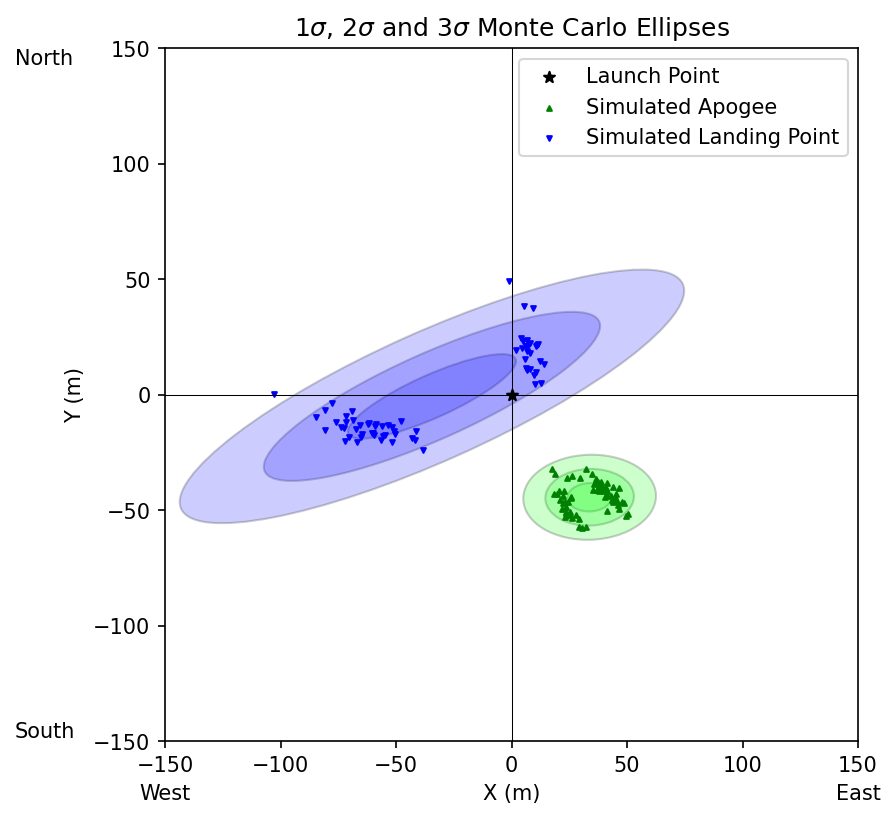

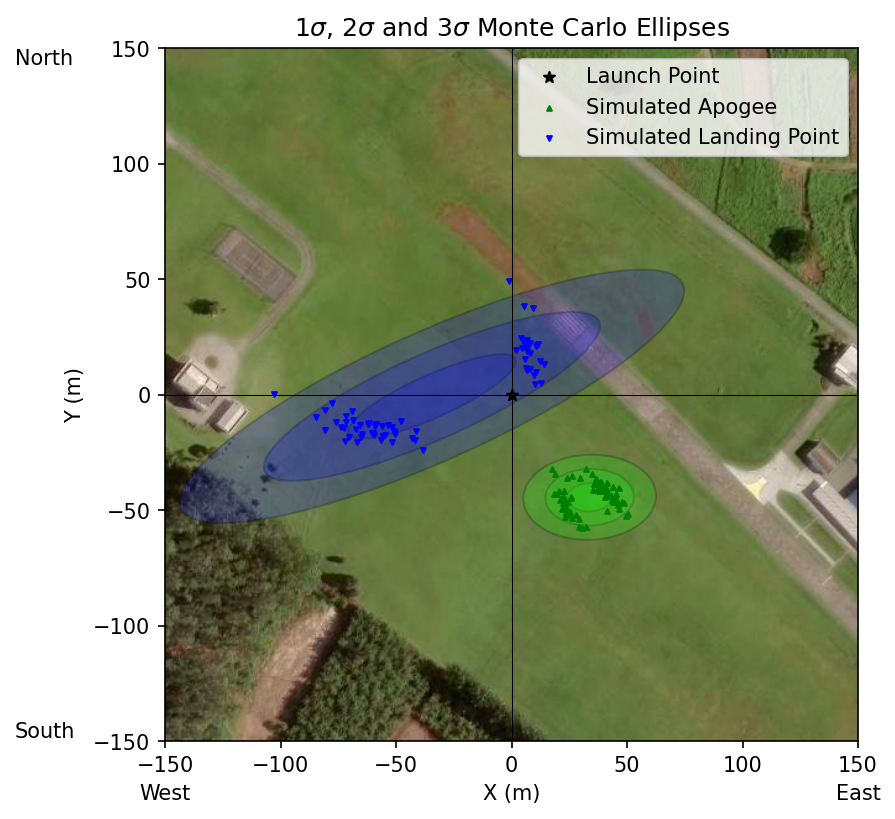

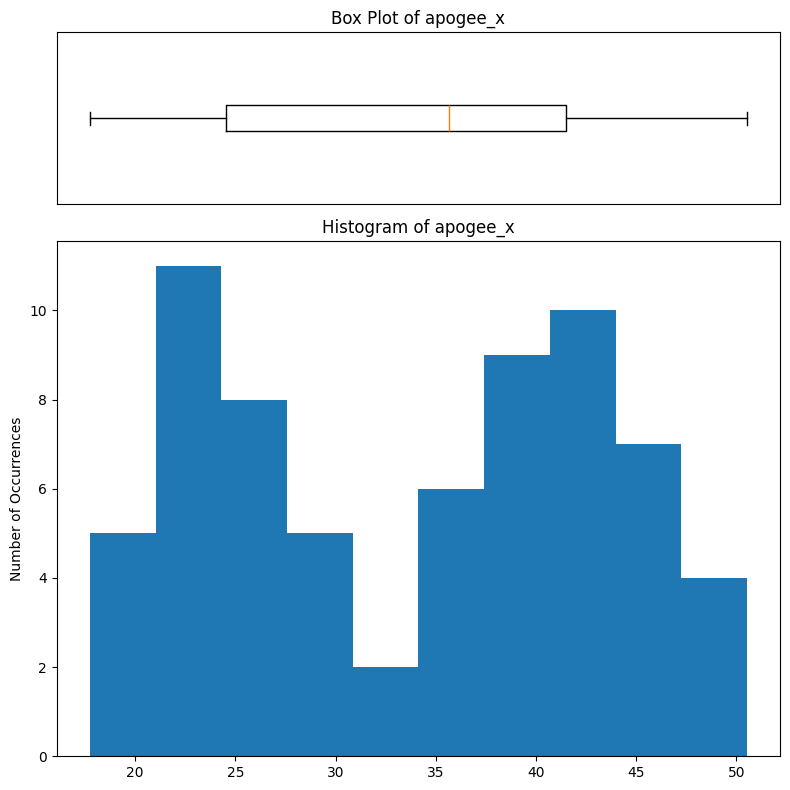

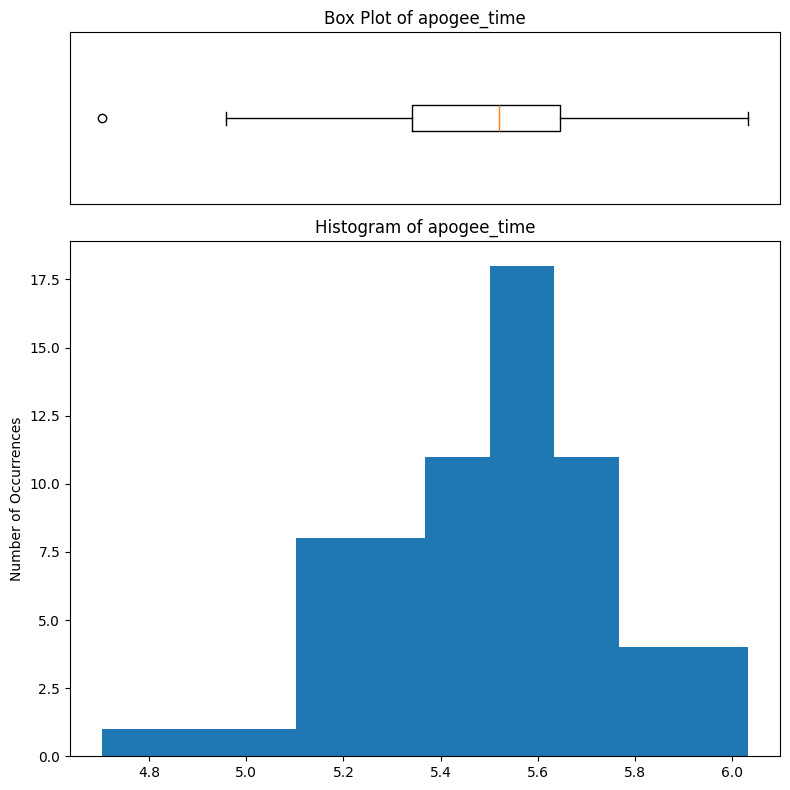

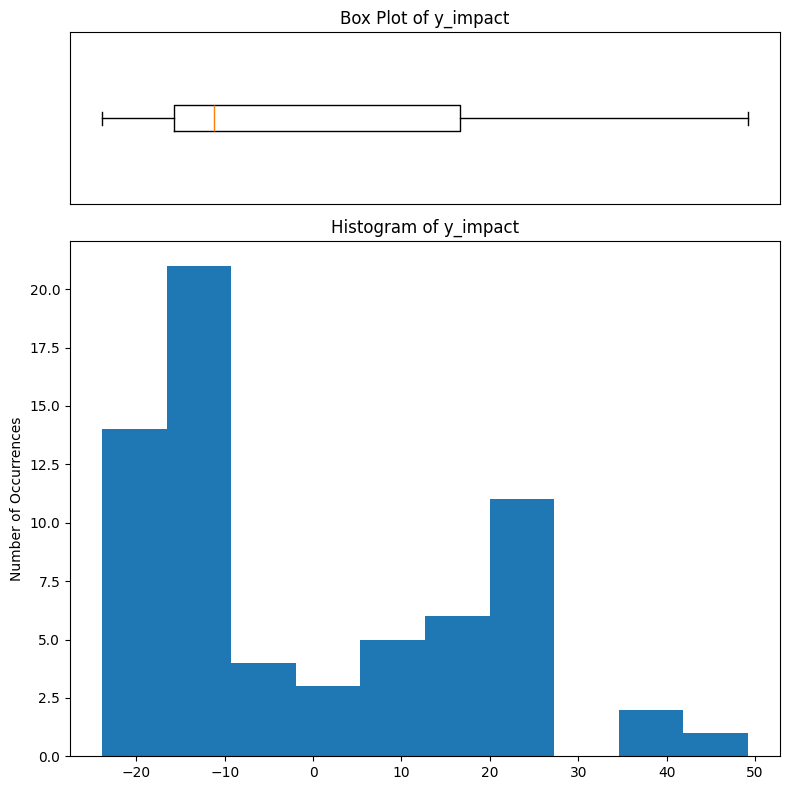

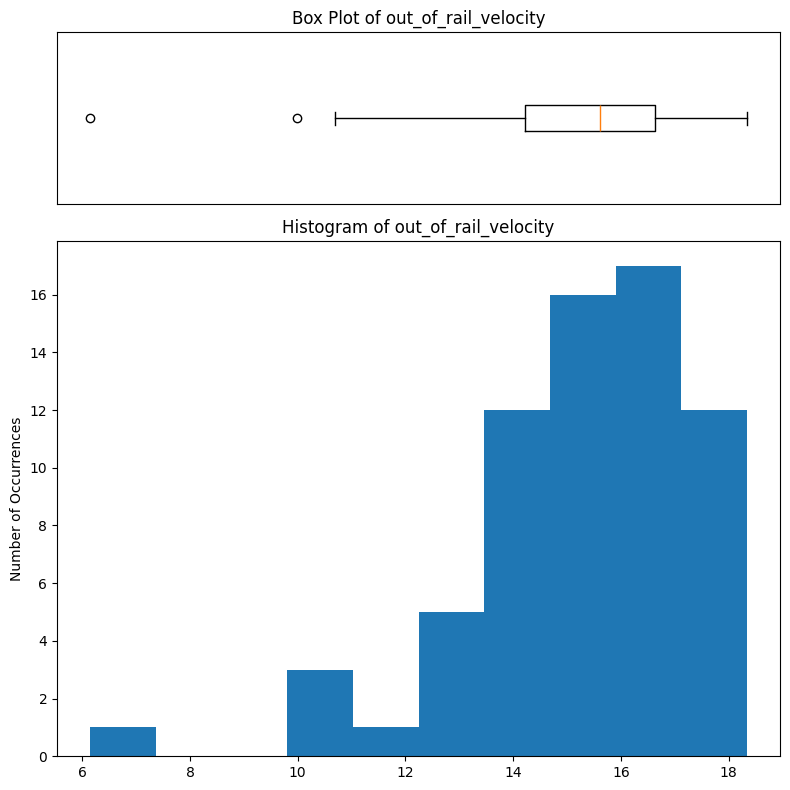

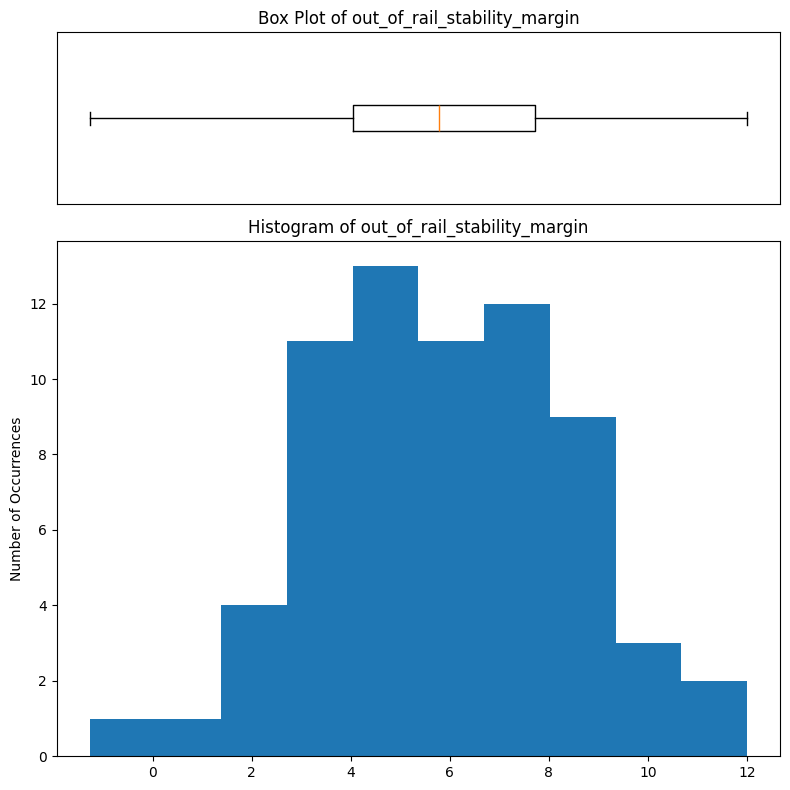

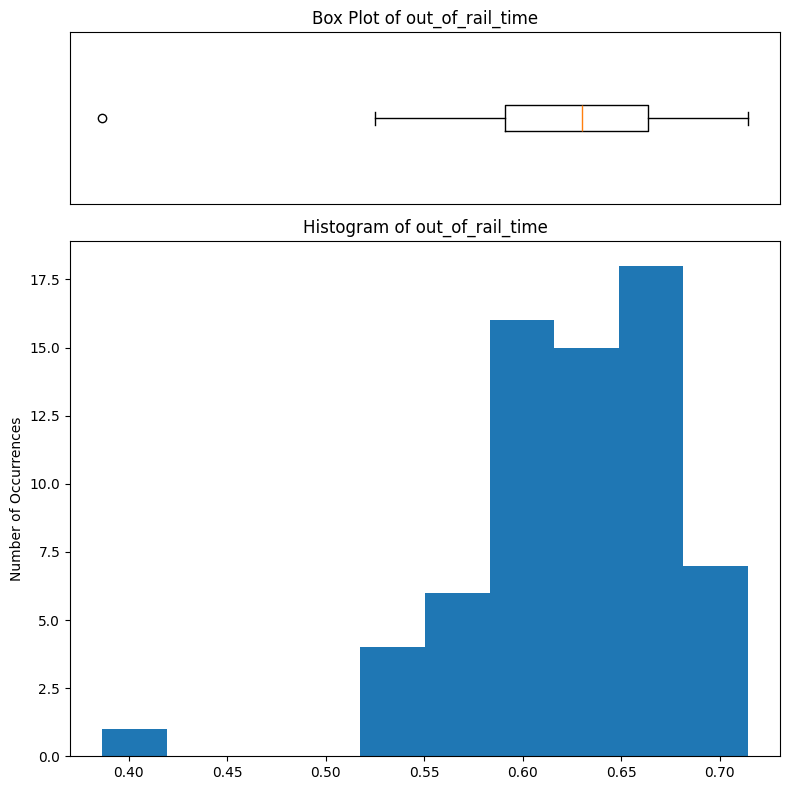

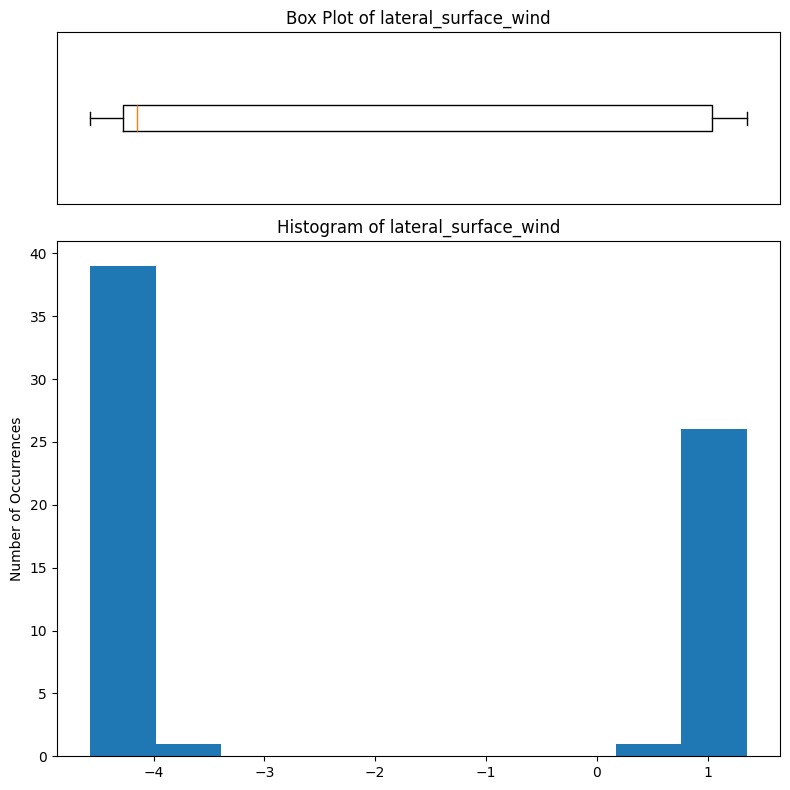

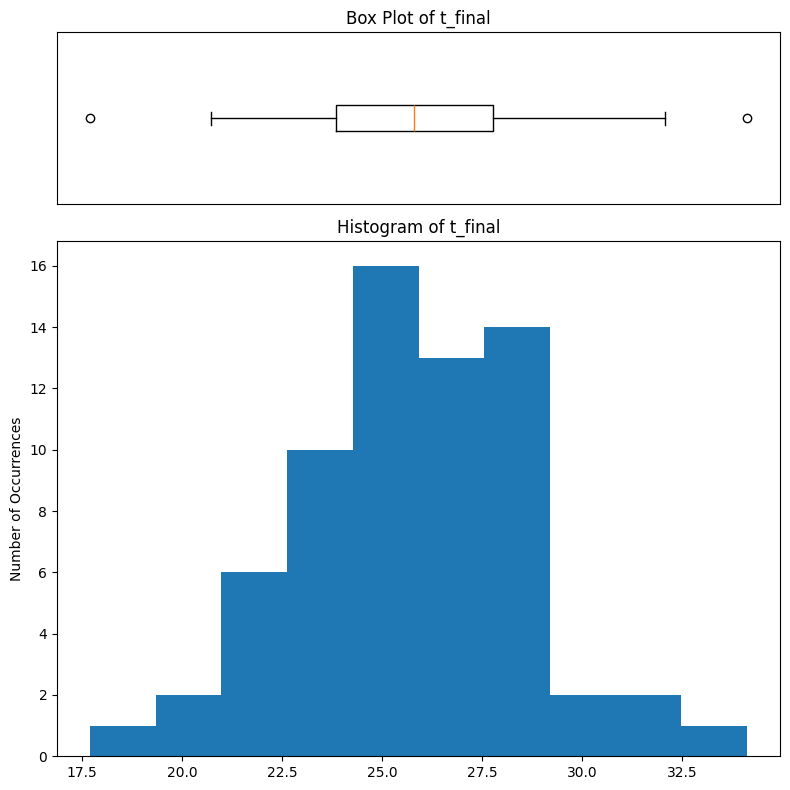

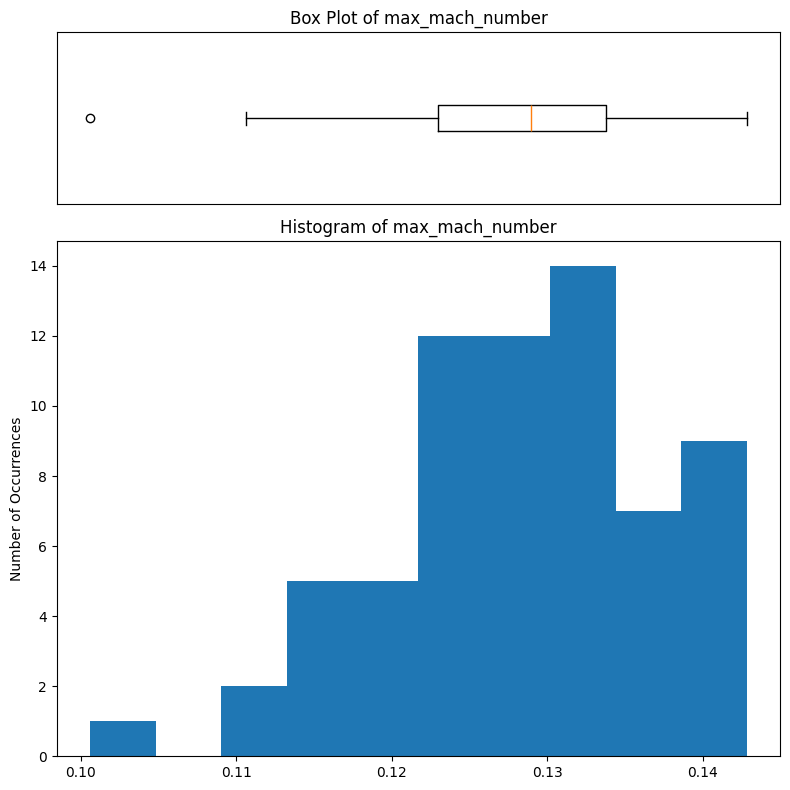

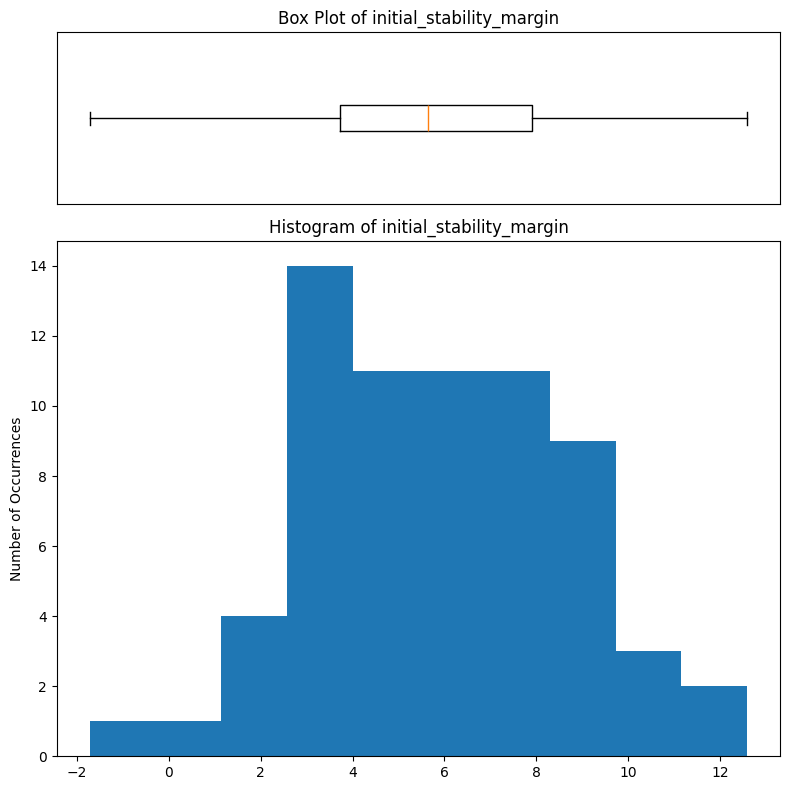

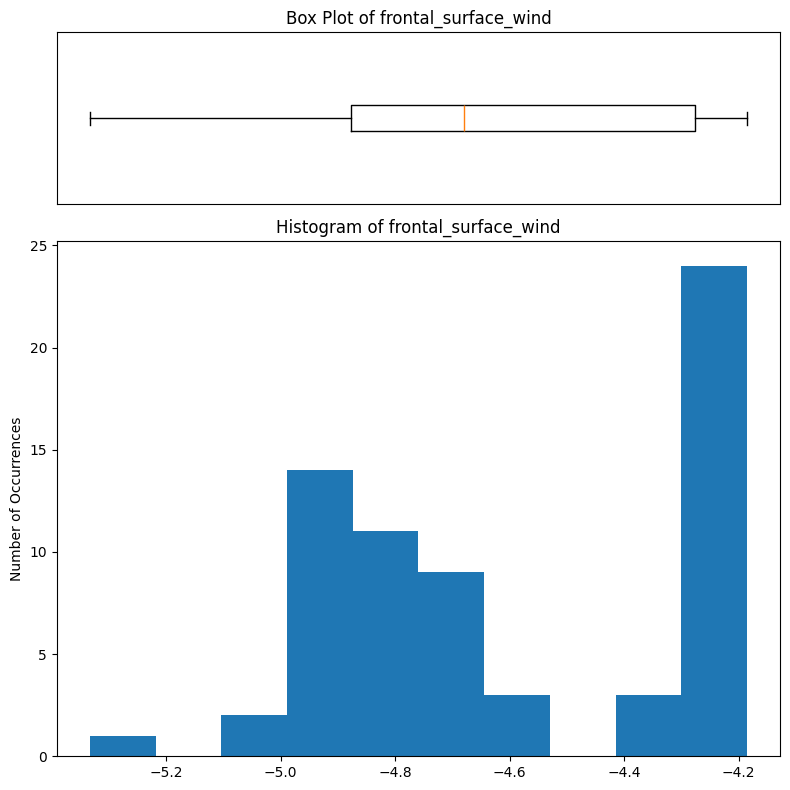

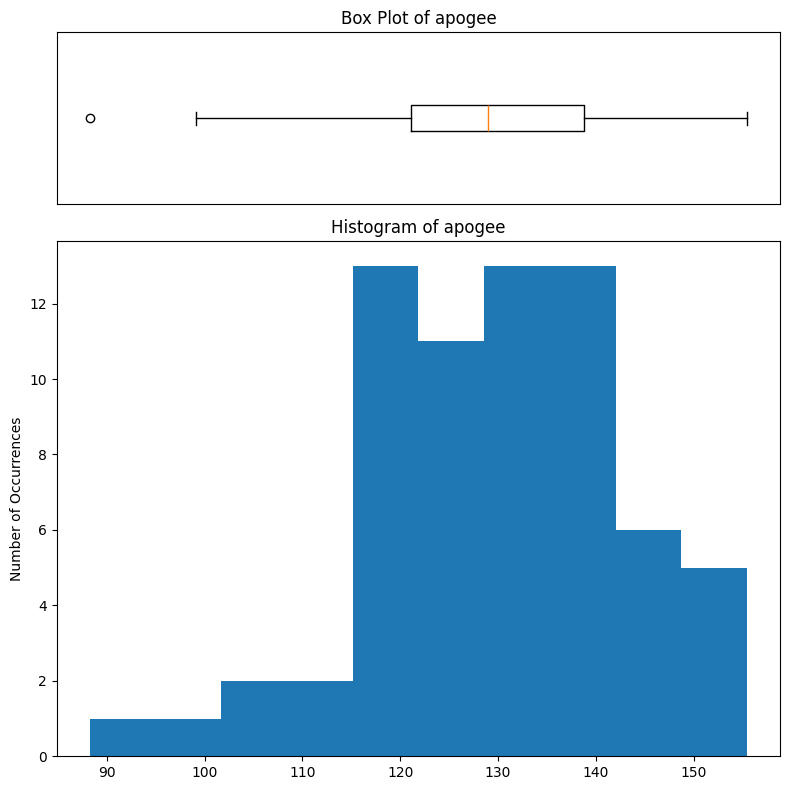

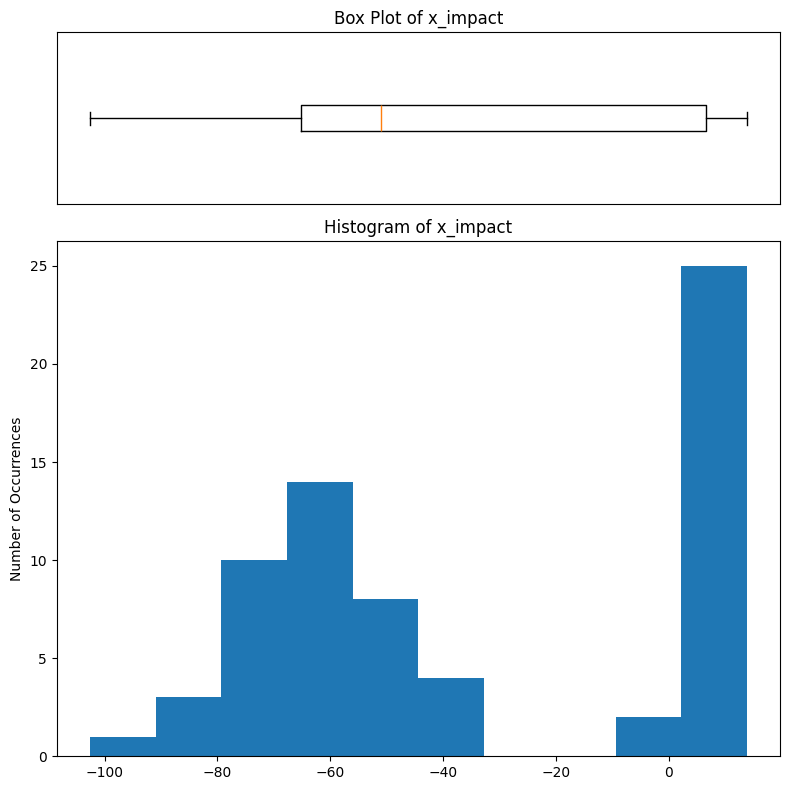

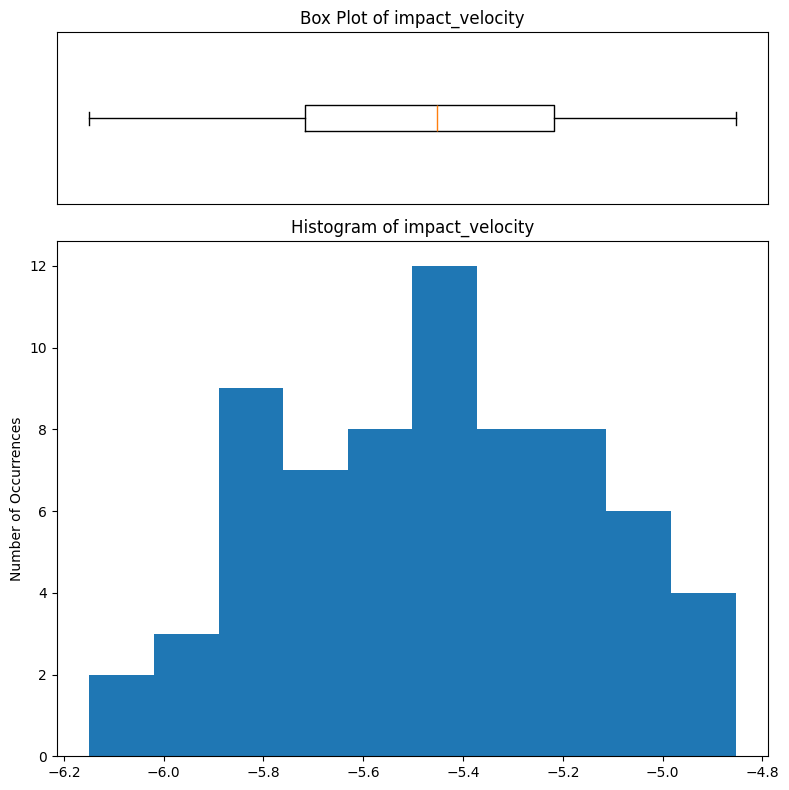

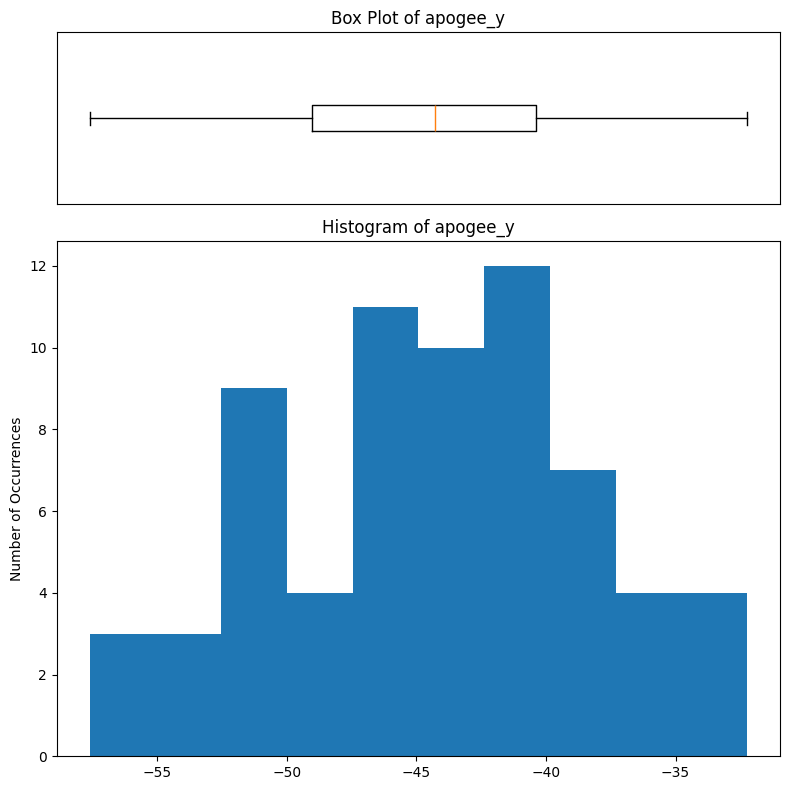

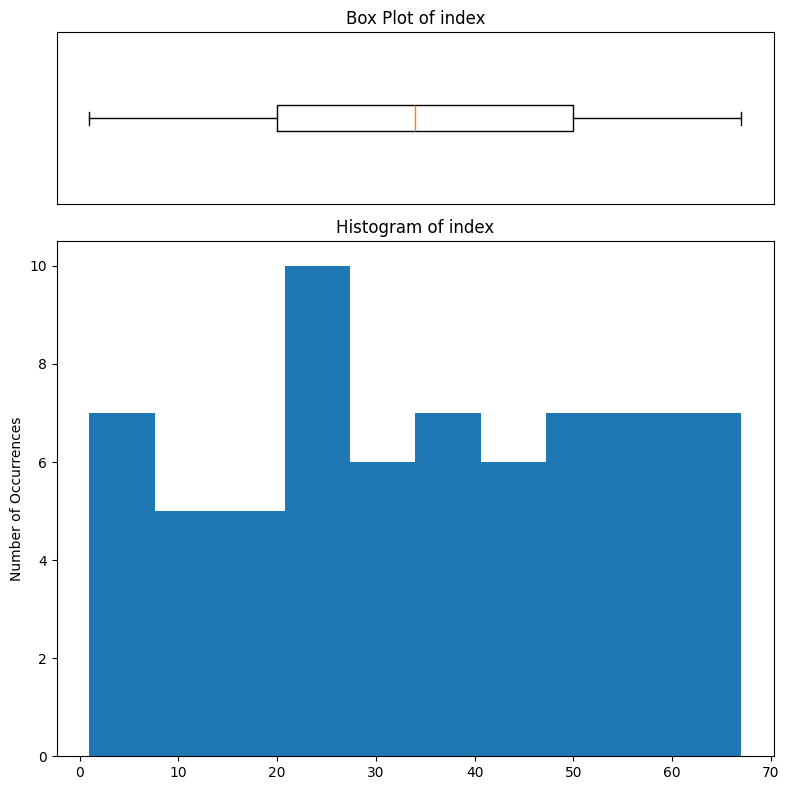

In [21]:
test_dispersion.plots.ellipses(xlim = (-150, 150), ylim = (-150, 150))
test_dispersion.plots.ellipses(
    background = "satellite", xlim = (-150, 150), ylim = (-150, 150)
)
test_dispersion.plots.all()

In [22]:
test_dispersion.export_ellipses_to_kml(
    filename = "MC.kml",
    origin_lat = env.latitude,
    origin_lon = env.longitude,
    type = "impact",
)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\rocketpy\tools.py:593: RuntimeWarning: Degrees of freedom <= 0 for slice
  covariance_matrix = np.cov(list_x, list_y)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\si

In [23]:
'''test_dispersion.simulate_convergence(
    target_attribute = "apogee",
    target_confidence = 0.95,
    tolerance = 2,              # Erro máximo aceitável da estimativa (m)
    max_simulations = 1000,
    batch_size = 50
)'''

'test_dispersion.simulate_convergence(\n    target_attribute = "apogee",\n    target_confidence = 0.95,\n    tolerance = 2,              # Erro máximo aceitável da estimativa (m)\n    max_simulations = 1000,\n    batch_size = 50\n)'

In [24]:
'''test_dispersion.plots.ellipses(xlim = (-150, 150), ylim = (-150, 150))
test_dispersion.plots.ellipses(
    background = "satellite", xlim = (-150, 150), ylim = (-150, 150)
)
test_dispersion.plots.all()'''

'test_dispersion.plots.ellipses(xlim = (-150, 150), ylim = (-150, 150))\ntest_dispersion.plots.ellipses(\n    background = "satellite", xlim = (-150, 150), ylim = (-150, 150)\n)\ntest_dispersion.plots.all()'

In [25]:
'''test_dispersion.export_ellipses_to_kml(
    filename = "MC_Convergence_0_vent0.kml",
    origin_lat = env.latitude,
    origin_lon = env.longitude,
    type = "impact",
)'''

'test_dispersion.export_ellipses_to_kml(\n    filename = "MC_Convergence_0_vent0.kml",\n    origin_lat = env.latitude,\n    origin_lon = env.longitude,\n    type = "impact",\n)'